# Semana 9: Procesamiento con Spark y EDA

## Analisis exploratorio de datos energeticos

**Integrante:** Thalia Gonzalez  
**Tema:** Impacto ambiental de la energia  
**Dataset:** Global Power Plant Database - World Resources Institute

Objetivo: limpiar y analizar plantas de generacion electrica para conocer la distribucion de capacidad instalada, comparar tecnologias y categorias energeticas, detectar valores atipicos y estudiar correlaciones.

## 1. Sesion Spark y librerias

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, count, isnan
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

spark = SparkSession.builder.appName("Semana9_EDA_Energia_Thalia").getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print("Spark funcionando")

Spark funcionando


## 2. Carga de datos

El codigo permite leer desde MongoDB si la coleccion esta disponible. Para que la actividad sea reproducible en el repositorio de practica, por defecto lee el CSV con 500 registros obtenido en el scraping.

In [2]:
USAR_MONGODB = False
MONGO_URI = os.getenv("MONGO_URI", "mongodb://database:27017/")
MONGO_DATABASE = os.getenv("MONGO_DATABASE", "proyecto_bigdata")
MONGO_COLLECTION = os.getenv("MONGO_COLLECTION", "energia_sustentabilidad")

if USAR_MONGODB:
    df_raw = (spark.read.format("mongodb")
        .option("spark.mongodb.read.connection.uri", MONGO_URI)
        .option("database", MONGO_DATABASE)
        .option("collection", MONGO_COLLECTION)
        .load())
    fuente = f"MongoDB: {MONGO_DATABASE}.{MONGO_COLLECTION}"
else:
    rutas = [Path("Energy/datos_auditoria_global.csv"), Path("../Energy/datos_auditoria_global.csv"), Path("../../Energy/datos_auditoria_global.csv")]
    ruta_csv = next(ruta for ruta in rutas if ruta.exists())
    df_raw = spark.read.option("header", True).option("inferSchema", True).csv(str(ruta_csv))
    fuente = str(ruta_csv)

print("Fuente cargada:", fuente)
print("Total registros crudos:", df_raw.count())
df_raw.printSchema()
df_raw.show(5, truncate=False)

Fuente cargada: ../Energy/datos_auditoria_global.csv
Total registros crudos: 500
root
 |-- fuente_sitio: string (nullable = true)
 |-- dataset: string (nullable = true)
 |-- url_origen: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- tema: string (nullable = true)
 |-- fecha_extraccion: timestamp (nullable = true)
 |-- pais: string (nullable = true)
 |-- region: string (nullable = true)
 |-- periodo: integer (nullable = true)
 |-- indicador: string (nullable = true)
 |-- categoria_energia: string (nullable = true)
 |-- tecnologia: string (nullable = true)
 |-- actor: string (nullable = true)
 |-- item: string (nullable = true)
 |-- valor: double (nullable = true)
 |-- unidad: string (nullable = true)

+-------------------------+---------------------------+------------------------------+---------------------------+-------------------------------+-------------------+-----------+------+-------+--------------------+-----------------+----------+---------------+-----------

## 3. Limpieza e inconsistencias

La llave logica para evitar duplicados combina `item`, `pais`, `tecnologia` y `periodo`. Se descartan registros sin identificacion, sin tecnologia o sin valor positivo.

In [3]:
registros_antes = df_raw.count()

df_clean = (df_raw
    .dropDuplicates(["item", "pais", "tecnologia", "periodo"])
    .filter(col("item").isNotNull())
    .filter(col("tecnologia").isNotNull())
    .filter(col("categoria_energia").isNotNull())
    .withColumn("capacidad_mw", col("valor").cast("double"))
    .filter(col("capacidad_mw").isNotNull() & (col("capacidad_mw") > 0)))

registros_despues = df_clean.count()
print("Registros antes de limpiar:", registros_antes)
print("Registros validos despues de limpiar:", registros_despues)
print("Registros descartados o duplicados:", registros_antes - registros_despues)

Registros antes de limpiar: 500
Registros validos despues de limpiar: 500
Registros descartados o duplicados: 0


## 4. Normalizacion e ingenieria de caracteristicas

Los registros ya usan una unidad comun (`MW`). Para reducir el sesgo provocado por plantas de capacidad muy alta se crea `capacidad_log`. Ademas, se crean variables que permiten analizar diferencias entre energias renovables y fosiles.

In [4]:
frecuencia_tecnologia = df_clean.groupBy("tecnologia").agg(F.count("*").alias("frecuencia_tecnologia"))

df_eda = (df_clean.join(frecuencia_tecnologia, "tecnologia", "left")
    .withColumn("es_renovable", when(col("categoria_energia") == "Renovable", F.lit(1.0)).otherwise(F.lit(0.0)))
    .withColumn("capacidad_log", F.log1p(col("capacidad_mw")))
    .withColumn("periodo_num", col("periodo").cast("double")))

df_eda.select("item", "categoria_energia", "tecnologia", "capacidad_mw", "capacidad_log", "frecuencia_tecnologia", "es_renovable").show(10, truncate=False)

+----------------------------------------------+-----------------+----------+------------+------------------+---------------------+------------+
|item                                          |categoria_energia|tecnologia|capacidad_mw|capacidad_log     |frecuencia_tecnologia|es_renovable|
+----------------------------------------------+-----------------+----------+------------+------------------+---------------------+------------+
|AGUA DEL CAJON (AUTOGENERADOR DEL MEM) - Other|Fosil            |Other     |479.2       |6.174202683787152 |3                    |0.0         |
|AGUA DEL CAJON (GENERADOR DEL MEM) - Gas      |Fosil            |Gas       |192.0       |5.262690188904886 |136                  |0.0         |
|AGUA DEL TORO - Hydro                         |Renovable        |Hydro     |130.0       |4.875197323201151 |96                   |1.0         |
|ALICURA - Hydro                               |Renovable        |Hydro     |1050.0      |6.957497370876951 |96                   

## 5. Analisis descriptivo y valores faltantes

In [5]:
print("Estadisticas de variables numericas:")
df_eda.select("capacidad_mw", "capacidad_log", "frecuencia_tecnologia", "es_renovable").describe().show()

print("Valores nulos por columna:")
df_eda.select([
    count(when(col(c).isNull() | (isnan(c) if dict(df_eda.dtypes)[c] in ["double", "float"] else F.lit(False)), c)).alias(c)
    for c in df_eda.columns
]).show(truncate=False)

Estadisticas de variables numericas:
+-------+------------------+------------------+---------------------+------------------+
|summary|      capacidad_mw|     capacidad_log|frecuencia_tecnologia|      es_renovable|
+-------+------------------+------------------+---------------------+------------------+
|  count|               500|               500|                  500|               500|
|   mean|151.67859399999998| 3.666723237516782|               96.088|              0.41|
| stddev| 295.2236412228107| 1.695618665613329|    38.65318088832496|0.4923258773811084|
|    min|               1.0|0.6931471805599453|                    2|               0.0|
|    max|            2640.0| 7.878912912297132|                  136|               1.0|
+-------+------------------+------------------+---------------------+------------------+

Valores nulos por columna:
+----------+------------+-------+----------+-----+----+----------------+----+------+-------+---------+-----------------+-----+----+---

## 6. Distribucion, skewness y segmentacion por cuartiles

La asimetria (`skewness`) permite revisar si la capacidad esta concentrada en plantas pequenas con unas pocas plantas grandes. Los cuartiles segmentan plantas segun tamano.

In [6]:
estadistica_skew = df_eda.select(
    F.skewness("capacidad_mw").alias("skewness_capacidad_mw"),
    F.skewness("capacidad_log").alias("skewness_capacidad_log")
)
estadistica_skew.show()

q1, mediana, q3 = df_eda.approxQuantile("capacidad_mw", [0.25, 0.50, 0.75], 0.01)
print("Cuartiles capacidad MW:", {"Q1": q1, "Mediana": mediana, "Q3": q3})

df_cuartiles = df_eda.withColumn(
    "segmento_capacidad",
    when(col("capacidad_mw") <= q1, "Baja")
    .when(col("capacidad_mw") <= q3, "Media")
    .otherwise("Alta")
)

df_cuartiles.groupBy("segmento_capacidad", "categoria_energia").agg(
    F.count("item").alias("plantas"),
    F.round(F.avg("capacidad_mw"), 2).alias("capacidad_promedio_mw")
).orderBy("segmento_capacidad", "categoria_energia").show(truncate=False)

+---------------------+----------------------+
|skewness_capacidad_mw|skewness_capacidad_log|
+---------------------+----------------------+
|    3.609085523225933|   0.26913362258446794|
+---------------------+----------------------+

Cuartiles capacidad MW: {'Q1': 10.0, 'Mediana': 30.0, 'Q3': 123.7}
+------------------+-----------------+-------+---------------------+
|segmento_capacidad|categoria_energia|plantas|capacidad_promedio_mw|
+------------------+-----------------+-------+---------------------+
|Alta              |Fosil            |96     |526.35               |
|Alta              |Renovable        |33     |444.29               |
|Baja              |Fosil            |80     |4.2                  |
|Baja              |Renovable        |43     |5.25                 |
|Media             |Fosil            |119    |34.98                |
|Media             |Renovable        |129    |45.92                |
+------------------+-----------------+-------+---------------------+



## 7. Analisis por grupos

Se comparan tecnologias y categorias energeticas para identificar cuales concentran mayor capacidad instalada promedio.

In [7]:
print("Capacidad promedio por tecnologia:")
(df_eda.groupBy("tecnologia", "categoria_energia")
    .agg(
        F.count("item").alias("plantas"),
        F.round(F.avg("capacidad_mw"), 2).alias("capacidad_promedio_mw"),
        F.round(F.max("capacidad_mw"), 2).alias("capacidad_maxima_mw")
    )
    .orderBy(F.desc("capacidad_promedio_mw"))
    .show(15, truncate=False))

print("Capacidad total y promedio por categoria energetica:")
(df_eda.groupBy("categoria_energia")
    .agg(
        F.count("item").alias("plantas"),
        F.round(F.sum("capacidad_mw"), 2).alias("capacidad_total_mw"),
        F.round(F.avg("capacidad_mw"), 2).alias("capacidad_promedio_mw")
    ).show(truncate=False))

Capacidad promedio por tecnologia:
+----------+-----------------+-------+---------------------+-------------------+
|tecnologia|categoria_energia|plantas|capacidad_promedio_mw|capacidad_maxima_mw|
+----------+-----------------+-------+---------------------+-------------------+
|Coal      |Fosil            |20     |682.67               |2640.0             |
|Nuclear   |Fosil            |4      |534.5                |745.0              |
|Other     |Fosil            |3      |474.15               |845.26             |
|Gas       |Fosil            |136    |265.84               |1217.7             |
|Hydro     |Renovable        |96     |159.97               |1550.0             |
|Wind      |Renovable        |42     |51.98                |240.0              |
|Solar     |Renovable        |65     |49.28                |500.0              |
|Biomass   |Renovable        |2      |34.0                 |38.0               |
|Oil       |Fosil            |117    |13.56                |58.0          

## 8. Correlacion multivariada: Pearson y Spearman

Pearson mide relaciones lineales; Spearman permite revisar relaciones monotonas cuando la distribucion de capacidad es asimetrica.

In [8]:
variables_corr = ["capacidad_mw", "capacidad_log", "frecuencia_tecnologia", "es_renovable"]
assembler_corr = VectorAssembler(inputCols=variables_corr, outputCol="features_corr", handleInvalid="skip")
df_corr = assembler_corr.transform(df_eda).select("features_corr")

pearson = Correlation.corr(df_corr, "features_corr", "pearson").head()[0].toArray()
spearman = Correlation.corr(df_corr, "features_corr", "spearman").head()[0].toArray()

pdf_pearson = pd.DataFrame(pearson, index=variables_corr, columns=variables_corr)
pdf_spearman = pd.DataFrame(spearman, index=variables_corr, columns=variables_corr)

print("Matriz Pearson:")
display(pdf_pearson.round(3))
print("Matriz Spearman:")
display(pdf_spearman.round(3))

Matriz Pearson:


,capacidad_mw,capacidad_log,frecuencia_tecnologia,es_renovable
capacidad_mw,1.000,0.744,-0.022,-0.142
capacidad_log,0.744,1.000,0.057,-0.045
frecuencia_tecnologia,-0.022,0.057,1.000,-0.473
es_renovable,-0.142,-0.045,-0.473,1.000


Matriz Spearman:


,capacidad_mw,capacidad_log,frecuencia_tecnologia,es_renovable
capacidad_mw,1.000,1.000,0.141,-0.018
capacidad_log,1.000,1.000,0.141,-0.018
frecuencia_tecnologia,0.141,0.141,1.000,-0.625
es_renovable,-0.018,-0.018,-0.625,1.000


## 9. Visualizaciones

Spark se usa para transformar y resumir; para graficar se convierte una muestra controlada a Pandas.

/tmp/ipykernel_1391/1822473936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x="categoria_energia", y="capacidad_mw", ax=axes[0], palette="Set2")


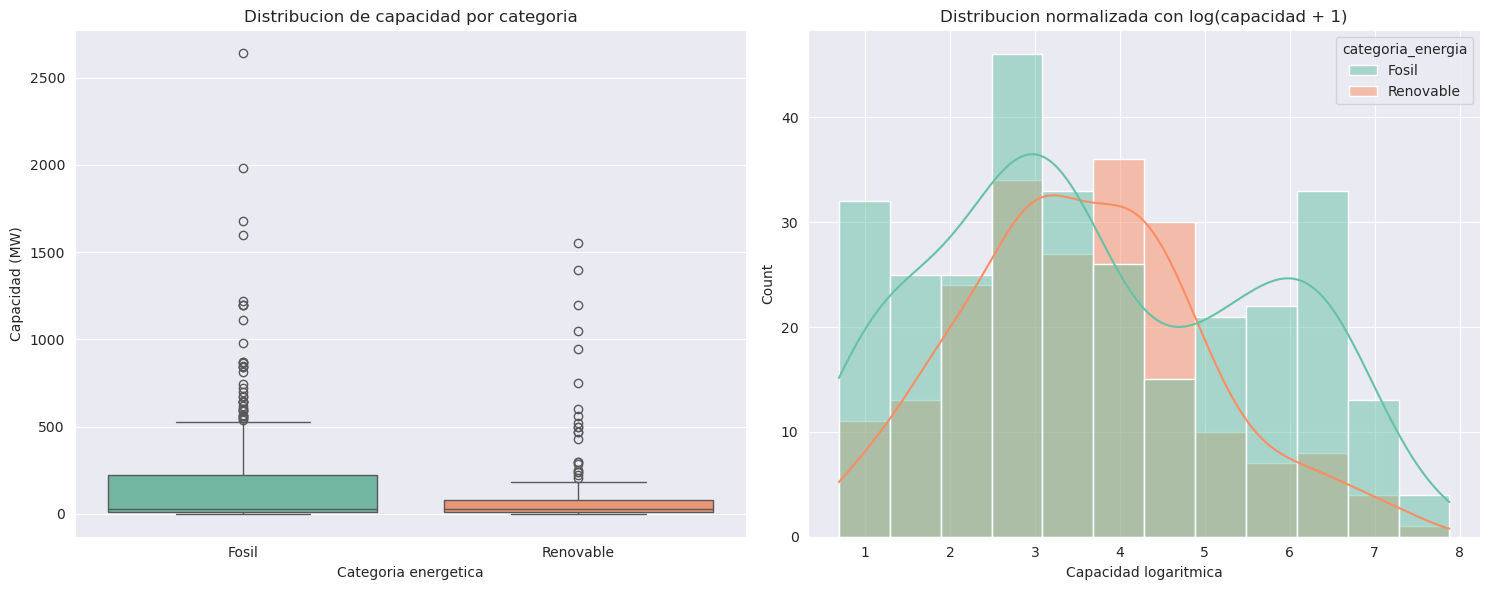

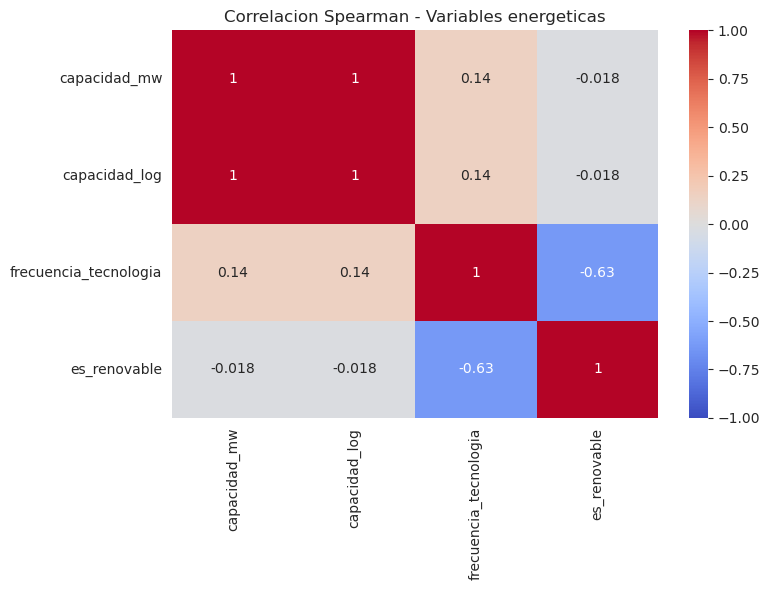

In [9]:
pdf = df_cuartiles.select("categoria_energia", "tecnologia", "capacidad_mw", "capacidad_log", "segmento_capacidad").toPandas()
sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=pdf, x="categoria_energia", y="capacidad_mw", ax=axes[0], palette="Set2")
axes[0].set_title("Distribucion de capacidad por categoria")
axes[0].set_xlabel("Categoria energetica")
axes[0].set_ylabel("Capacidad (MW)")

sns.histplot(data=pdf, x="capacidad_log", hue="categoria_energia", kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion normalizada con log(capacidad + 1)")
axes[1].set_xlabel("Capacidad logaritmica")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(pdf_spearman, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlacion Spearman - Variables energeticas")
plt.tight_layout()
plt.show()

## 10. Conclusion

- Se procesaron 500 registros del sector energetico con una unidad comparable: MW.
- La transformacion logaritmica permite analizar capacidades sin que unas pocas plantas grandes dominen la distribucion.
- Los cuartiles distinguen plantas de capacidad baja, media y alta para apoyar decisiones de priorizacion.
- Las matrices Pearson y Spearman permiten estudiar si la capacidad se relaciona con la categoria energetica o la frecuencia de cada tecnologia.
- Este EDA deja los datos preparados para Semana 10, donde se podran formar clusters de plantas con perfiles similares.